In [1]:
import matplotlib.pyplot as plt
import numpy as np
import common
from dataclasses import dataclass
from typing import List, Tuple

In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
@dataclass
class LinePlotData:
    x: List[float]
    y: List[float]
    name: str

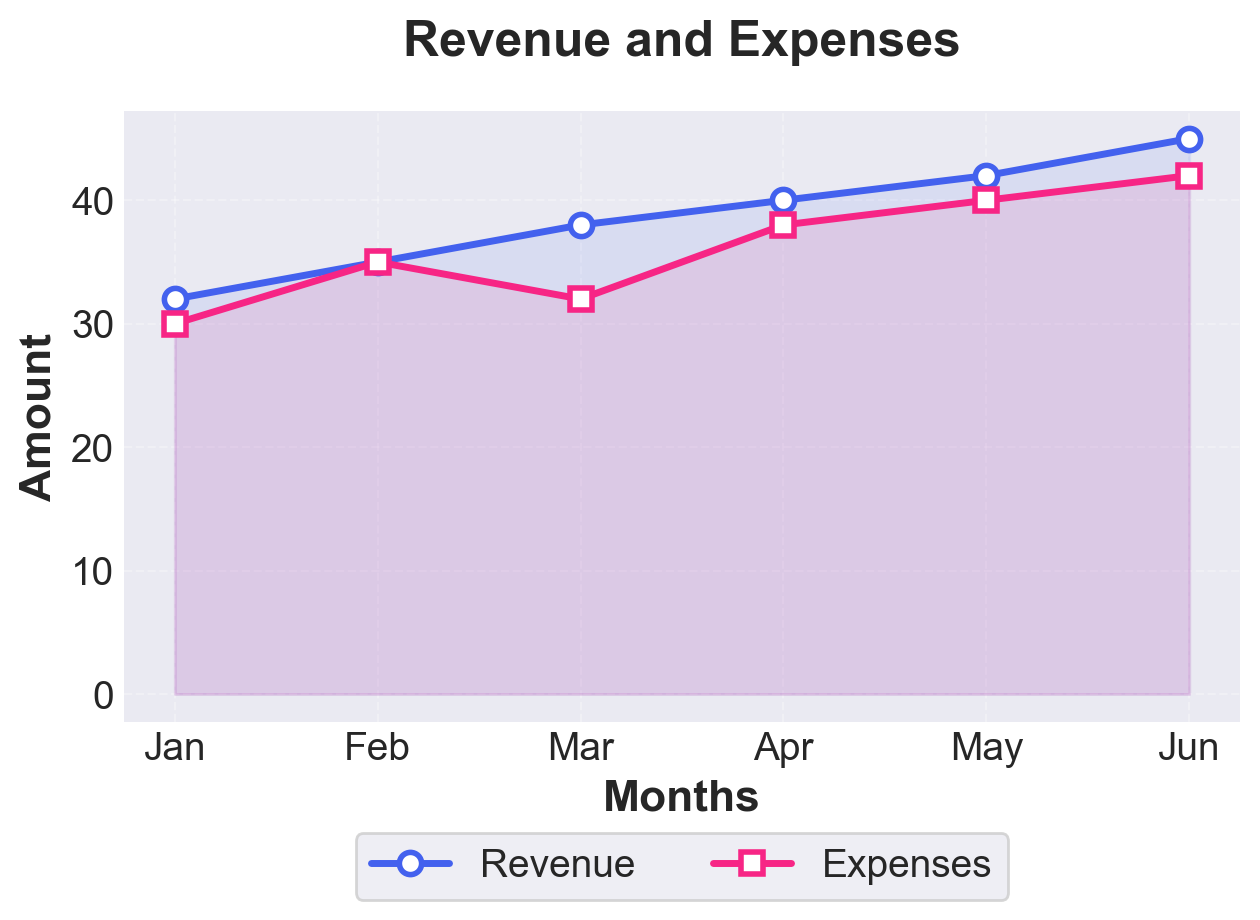

In [4]:
def generate_line_plot(
    data_list: List[LinePlotData], 
    x_label: str, 
    y_label: str, 
    title: str,
    x_ticks: Tuple[List[int], List[str]],
    show_legend: bool = True, 
    show_grid: bool = True, 
    num_legend_cols: int = 2,
    show_area_under_curve: bool = False,
    ):
    for idx, line_data in enumerate(data_list):
        plt.plot(
                line_data.x, 
                line_data.y, 
                marker=common.MARKERS[idx], 
                linewidth=common.LINE_WIDTH, 
                markersize=common.MARKER_SIZE, 
                color=common.COLORS[idx], 
                label=line_data.name, 
                markerfacecolor=common.MARKERFACECOLOR, 
                markeredgewidth=common.MARKEREDGEWIDTH, 
                markeredgecolor=common.COLORS[idx]
                )

        if show_area_under_curve:
            plt.fill_between(line_data.x, line_data.y, alpha=0.1, color=common.COLORS[idx])

    plt.xlabel(x_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.ylabel(y_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.title(title, fontsize=common.TITLE_SIZE, fontweight='bold', pad=20)
    plt.xticks(fontsize=common.X_TICK_FONT_SIZE)
    plt.yticks(fontsize=common.Y_TICK_FONT_SIZE)

    if x_ticks:
        plt.xticks(x_ticks[0], x_ticks[1], fontsize=common.X_TICK_FONT_SIZE)

    if show_legend:
        # put legend below the plot
        plt.legend(frameon=True, fontsize=common.LEGEND_FONT_SIZE, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=num_legend_cols)

    if show_grid:
        plt.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()


# Generate sample data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
data_list = [
        LinePlotData(x=[0, 1, 2, 3, 4, 5], y=[32, 35, 38, 40, 42, 45], name='Revenue'),
        LinePlotData(x=[0, 1, 2, 3, 4, 5], y=[30, 35, 32, 38, 40, 42], name='Expenses'),
]


generate_line_plot(
        data_list=data_list,
        x_label='Months',
        y_label='Amount',
        title='Revenue and Expenses',
        x_ticks=[
            list(range(len(months))),
            months
        ],
        show_legend=True,
        show_grid=True,
        show_area_under_curve=True
)
plt.show()

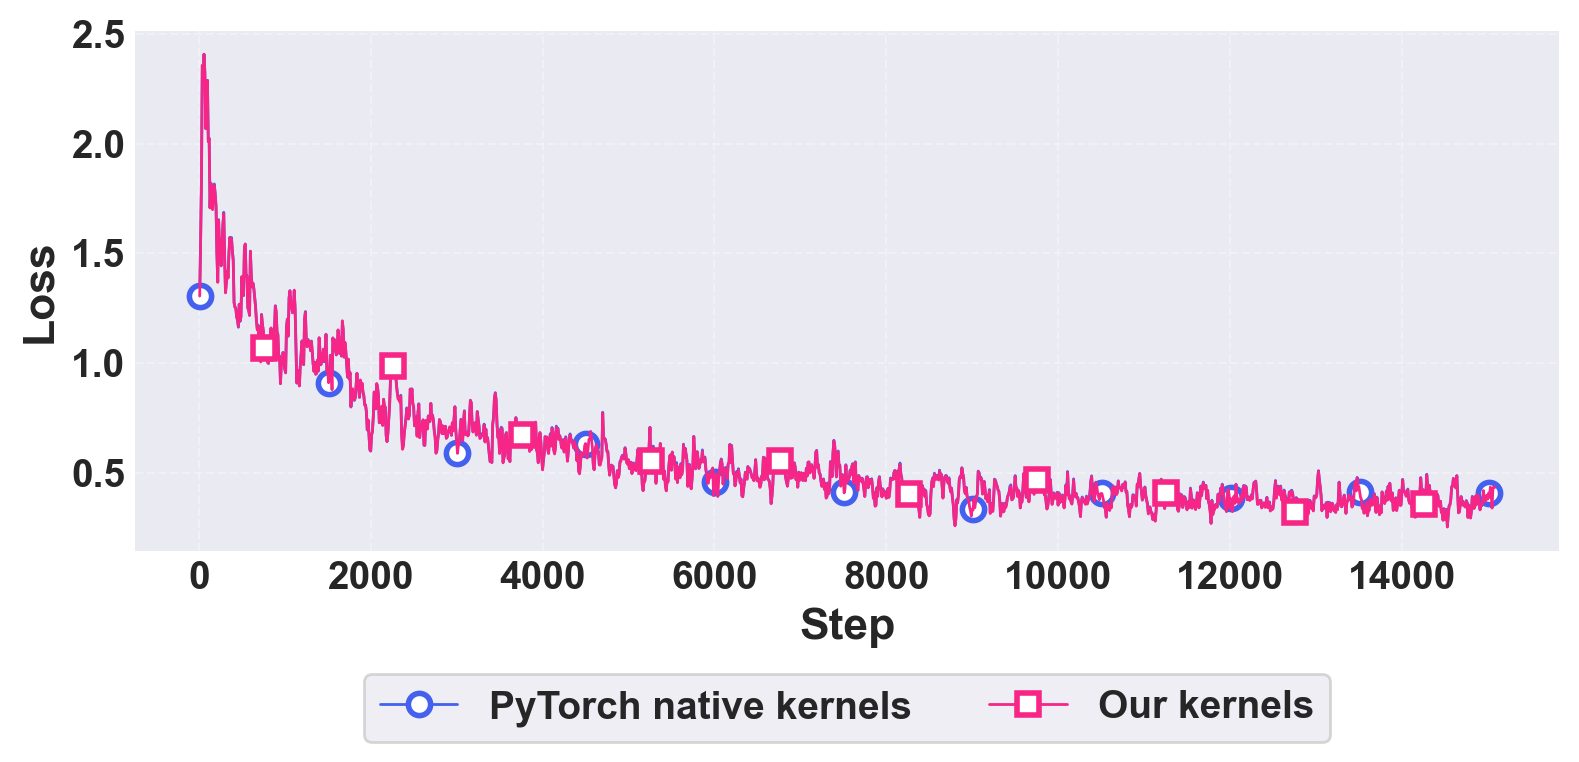

In [24]:
import csv

from matplotlib import markers

CSV_PATH = "wandb_export_2026-05-29T17_59_58.079+08_00.csv"

def read_csv_columns(path, col_names):
    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        rows = {c: [] for c in col_names}
        for row in reader:
            for c in col_names:
                val = row.get(c, "")
                rows[c].append(float(val) if val not in ("", "NaN") else float("nan"))
    return {c: np.array(v) for c, v in rows.items()}

cols = read_csv_columns(CSV_PATH, [
    "Step",
    "llama3-8b-baseline - train/ploss_6",
    "llama3-8b-ours - train/ploss_6",
])

steps    = cols["Step"]
baseline = cols["llama3-8b-baseline - train/ploss_6"]
ours     = cols["llama3-8b-ours - train/ploss_6"]

def ema_smooth(values, span=50):
    alpha = 2.0 / (span + 1)
    result = np.empty_like(values)
    result[0] = values[0]
    for i in range(1, len(values)):
        if np.isnan(values[i]):
            result[i] = result[i - 1]
        else:
            result[i] = alpha * values[i] + (1 - alpha) * result[i - 1]
    return result

SMOOTH_SPAN = 5
baseline_smooth = ema_smooth(baseline, SMOOTH_SPAN)
ours_smooth     = ema_smooth(ours, SMOOTH_SPAN)

COLOR_BASELINE = common.COLORS[0]
COLOR_OURS     = common.COLORS[1]

plt.figure(figsize=(8, 4))

# plt.plot(steps, baseline, color=COLOR_BASELINE, alpha=0.2, linewidth=0.8, label="_nolegend_")
# plt.plot(steps, ours,     color=COLOR_OURS,     alpha=0.2, linewidth=0.8, label="_nolegend_")

MARK_STEP  = len(steps) // 10
MARK_OFFSET = MARK_STEP // 2

plt.plot(steps, baseline_smooth, color=COLOR_BASELINE, linewidth=1,
         marker=common.MARKERS[0], markersize=common.MARKER_SIZE,
         markerfacecolor=common.MARKERFACECOLOR, markeredgewidth=common.MARKEREDGEWIDTH,
         markeredgecolor=COLOR_BASELINE, markevery=(0, MARK_STEP),
         label="PyTorch native kernels")
plt.plot(steps, ours_smooth, color=COLOR_OURS, linewidth=1,
         marker=common.MARKERS[1], markersize=common.MARKER_SIZE,
         markerfacecolor=common.MARKERFACECOLOR, markeredgewidth=common.MARKEREDGEWIDTH,
         markeredgecolor=COLOR_OURS, markevery=(MARK_OFFSET, MARK_STEP),
         label="Our kernels")

plt.xlabel("Step", fontsize=common.LABEL_FONT_SIZE, fontweight="bold")
plt.ylabel("Loss",  fontsize=common.LABEL_FONT_SIZE, fontweight="bold")
# plt.title("Training Loss for TTT = 7", fontsize=common.TITLE_SIZE, fontweight="bold", pad=20)
plt.xticks(fontsize=common.X_TICK_FONT_SIZE, fontweight="bold")
plt.yticks(fontsize=common.Y_TICK_FONT_SIZE, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(
    frameon=True,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,
    prop={"weight": "bold", "size": 14},
)

plt.tight_layout()
plt.savefig("plots/plot_kernel_impact_on_loss.pdf", dpi=300)
plt.show()